In [54]:
import pandas as pd
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

In [55]:
## Definition of a hyperparameter grid:
learning_rate_variants = [0.001]
batch = 250
hidden_layer_variants = [[10,10,10], [32,16,8], [64,32,16], [128, 64, 32], [128, 64, 32, 16]] #Testwerte für die Grid aktuell
input_layer = 22 #Number of features
epochs = 4

In [56]:
## Import the data-splits:
df_train = pd.read_parquet("../data/df_train.parquet")
df_val = pd.read_parquet("../data/df_val.parquet")
df_test = pd.read_parquet("../data/df_test.parquet")
print(f"Train split loaded. Shape: {df_train.shape}")
print(f"Validation split loaded. Shape: {df_val.shape}")
print(f"Test split loaded. Shape: {df_test.shape}")

Train split loaded. Shape: (4641696, 36)
Validation split loaded. Shape: (1852320, 36)
Test split loaded. Shape: (2778934, 36)


In [57]:
## Preparing the data for training the Deep NN:

target = 'Total_Trip_Start'  # Assuming this is the target variable in the dataset
features = [
    'distance_to_loop',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'is_weekend', 'is_holiday', 'day_of_week',
    'poi_cat_automotive', 'poi_cat_civic_community', 'poi_cat_education',
    'poi_cat_entertainment', 'poi_cat_finance', 'poi_cat_food_drink',
    'poi_cat_grocery', 'poi_cat_health', 'poi_cat_leisure_sports',
    'poi_cat_lodging', 'poi_cat_nightlife', 'poi_cat_services','poi_cat_shopping', 'poi_cat_transport'
]

# Scaling
x_scaler = StandardScaler()
y_scaler = StandardScaler()
x_scaler.fit(df_train[features])

X_train_scaled = x_scaler.transform(df_train[features])
y_train = df_train[target].values
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).squeeze()

X_val_scaled = x_scaler.transform(df_val[features])
y_val = df_val[target].values
y_val_scaled   = y_scaler.transform(y_val.reshape(-1, 1)).squeeze()

X_test_scaled = x_scaler.transform(df_test[features])
y_test = df_test[target].values
y_test_scaled   = y_scaler.transform(y_test.reshape(-1, 1)).squeeze()

# Convert the numpy arrays into tensors:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

# Create tensor datasets, so we can then use them for our DataLoaders
train_set = TensorDataset(X_train_t, y_train_t)
validation_set = TensorDataset(X_val_t,   y_val_t)
test_set = TensorDataset(X_test_t,  y_test_t)

# Create the DataLoaders:
train_loader = DataLoader(train_set, batch_size=batch, shuffle=True)
validation_loader = DataLoader(validation_set, batch_size=batch, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch, shuffle=True)



In [58]:
# Definition of the feedforward NN:
# Notes: We make the number of hidden layers with the number of neurons dynamic, so we can try out different complexities in our grid-search
class FNN(nn.Module):
    def __init__(self, input_size, hidden_layers):
        super(FNN, self).__init__()
        self.layers = nn.ModuleList()
        prev_size = input_size
        for hidden_size in hidden_layers:
            self.layers.append(nn.Linear(prev_size, hidden_size))
            prev_size = hidden_size

        self.output_layer = nn.Linear(prev_size, 1)

    def forward(self, x):
        for layer in self.layers:
            x = F.relu(layer(x))
        return self.output_layer(x).squeeze(1)


In [59]:
# Definition of the training loop:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")

def train_model(FNN, device, train_loader, optimizer, loss_funct, epochs):
    FNN.train()
    loss_total = 0.0
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = FNN(inputs)
        loss = loss_funct(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_total += loss.item()
        running_loss += loss.item()
        if(i+1) % 250 == 0:
            print(f'TRAINING Epoch {epochs}, Batch {i+1}, Loss: {running_loss / 250}')
            running_loss = 0.0
    loss_avg = loss_total / len(train_loader)
    print(f'TRAINING Epoch {epochs}, Loss: {loss_avg}')
    return loss_avg



In [60]:
def validate_model(FNN, device, validation_loader, loss_funct):
    print(f' Predicting on Validation...')
    FNN.eval()
    loss_total = 0.0
    with torch.no_grad():
        for inputs, labels in validation_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = FNN(inputs)
            loss = loss_funct(outputs, labels)
            loss_total += loss.item()
    loss_avg = loss_total / len(validation_loader)
    print(f'VALIDATION, Loss: {loss_avg}')
    return loss_avg


In [61]:
# Grid-search for each hyperparameter combination defined before.
# Train the model for each batch in one epoch and validate the model after each epoch on the validation set

from IPython.display import clear_output, display ## Use: clear the output cell -> print out the results_df

loss_funct = nn.MSELoss()
results_df = pd.DataFrame(columns=['config', 'epoch', 'train_loss', 'val_loss']) #To save the train/val losses per configuration

for hidden_variant in hidden_layer_variants:
    for learning_rate in learning_rate_variants:
        config_name = f'layers={hidden_variant}_lr={learning_rate}'
        model = FNN(input_layer, hidden_variant).to(device)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate) #Adam is much more stable compared to SGD
        for epoch_index in range(1, epochs+1):
            print(f'\n########### Training: {config_name} ###########')
            train_loss = train_model(model, device, train_loader, optimizer, loss_funct, epoch_index)
            val_loss   = validate_model(model, device, validation_loader, loss_funct)

            if val_loss < results_df[results_df['config'] == config_name]['val_loss'].min(): #Always save the model with the lowest val_loss for early stopping
                torch.save(model.state_dict(), f'../plots/best_{config_name}.pth')

            results_df.loc[len(results_df)] = {
                'config': config_name,
                'epoch': epoch_index,
                'train_loss': train_loss,
                'val_loss': val_loss
            }
            clear_output(wait=True) # clears the output-cell
            display(results_df.set_index(['config', 'epoch']))  # nicer presentation of the training progress



hidden_layers  learning_rate  train_loss  \
config                        epoch                                             
layers=[64, 32, 16]_lr=0.001  1                NaN            NaN    0.209387   
                              2                NaN            NaN    0.156987   
                              3                NaN            NaN    0.143678   
                              4                NaN            NaN    0.133261   
layers=[128, 64, 32]_lr=0.001 1                NaN            NaN    0.197580   

                                     val_loss  
config                        epoch            
layers=[64, 32, 16]_lr=0.001  1      0.224240  
                              2      0.163448  
                              3      0.157033  
                              4      0.151345  
layers=[128, 64, 32]_lr=0.001 1      0.191021


########### Training: layers=[128, 64, 32]_lr=0.001 ###########
TRAINING Epoch 2, Batch 250, Loss: 0.12960390032734723
TRAINING Epoch 2, Batch 500, Loss: 0.16513063622685148
TRAINING Epoch 2, Batch 750, Loss: 0.1520492838586215
TRAINING Epoch 2, Batch 1000, Loss: 0.1358873971796129
TRAINING Epoch 2, Batch 1250, Loss: 0.12049105156888254
TRAINING Epoch 2, Batch 1500, Loss: 0.14535793394455687
TRAINING Epoch 2, Batch 1750, Loss: 0.14084021792327986
TRAINING Epoch 2, Batch 2000, Loss: 0.15649150015111082
TRAINING Epoch 2, Batch 2250, Loss: 0.15967769967508502
TRAINING Epoch 2, Batch 2500, Loss: 0.14048976015252992
TRAINING Epoch 2, Batch 2750, Loss: 0.18744145511463284
TRAINING Epoch 2, Batch 3000, Loss: 0.16387387794535607
TRAINING Epoch 2, Batch 3250, Loss: 0.1399180474295281
TRAINING Epoch 2, Batch 3500, Loss: 0.1504782280777581
TRAINING Epoch 2, Batch 3750, Loss: 0.14675535087194294
TRAINING Epoch 2, Batch 4000, Loss: 0.14846060603251682
TRAINING Epoch 2, Batch 4250, Loss: 0.12992743

KeyboardInterrupt: 

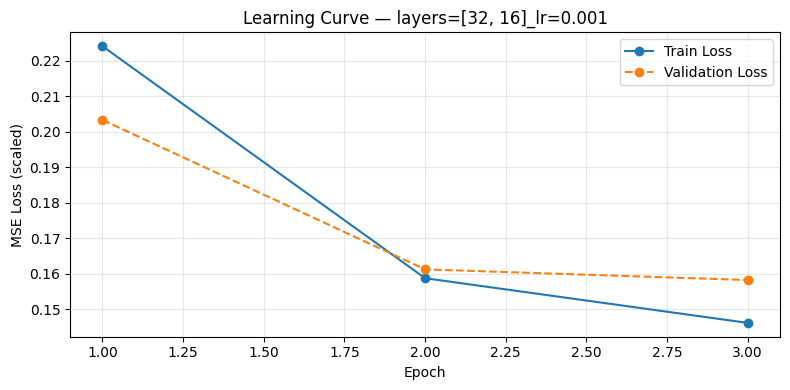

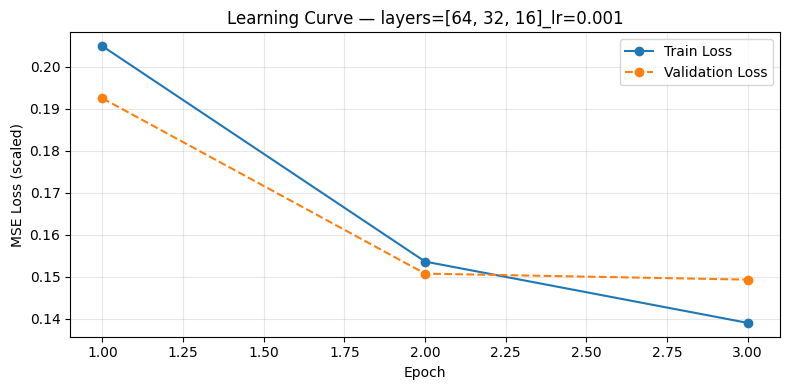

In [45]:
## Visualization of the trained NNs during grid search
for config_name in results_df['config'].unique():
    group = results_df[results_df['config'] == config_name]
    plt.figure(figsize=(8, 4))
    plt.plot(group['epoch'], group['train_loss'], label='Train Loss', marker='o')
    plt.plot(group['epoch'], group['val_loss'], label='Validation Loss', marker='o', linestyle='--')
    plt.title(f'Train vs. Validation Loss: {config_name}')
    plt.xlabel('Epoch')
    plt.xticks(range(1, epochs + 1))
    plt.ylabel('MSE Loss (scaled)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'../plots/learning_curve_{config_name}.png', dpi=150)
    plt.show()


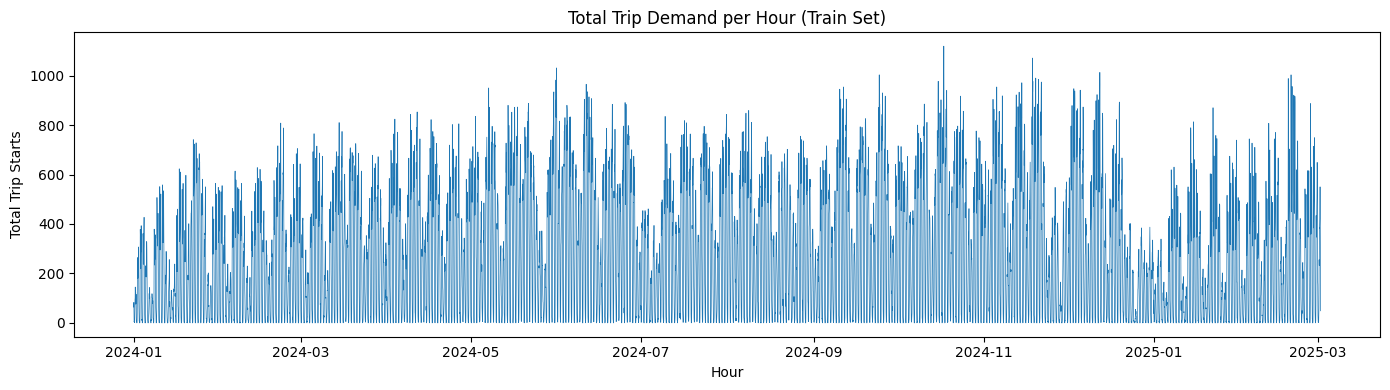

In [25]:
hourly_total = df_train.groupby('hour')['Total_Trip_Start'].sum()

plt.figure(figsize=(14, 4))
plt.plot(hourly_total.index, hourly_total.values, linewidth=0.5)
plt.title('Total Trip Demand per Hour (Train Set)')
plt.xlabel('Hour')
plt.ylabel('Total Trip Starts')
plt.tight_layout()
plt.show()